<a href="https://colab.research.google.com/github/Athulrajk1/-airport-maintenance-log-triage/blob/main/airport_maintenance_log_triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q sentence-transformers transformers torch pandas matplotlib scikit-learn ipywidgets --upgrade

In [3]:
import pandas as pd
import numpy as np
import random
import torch
from transformers import pipeline
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import ipywidgets as widgets
from IPython.display import display, clear_output

random.seed(42)
np.random.seed(42)

DEVICE = 0 if torch.cuda.is_available() else -1
print("Using GPU" if DEVICE == 0 else "Using CPU")

Using CPU


In [14]:
TAXONOMY = [
    "Electrical", "HVAC", "Hydraulic", "Brake system",
    "Engine / mechanical", "Body / chassis", "Tires / wheels",
    "Fuel system", "Safety equipment"
]

VEHICLE_TYPES = {
    "Ambulance": {"tier": "Critical", "department": "Medical",
                  "common_categories": ["HVAC", "Electrical", "Engine / mechanical", "Safety equipment"]},
    "Fire truck": {"tier": "Critical", "department": "Fire & safety",
                   "common_categories": ["Hydraulic", "Brake system", "Engine / mechanical", "Safety equipment"]},
    "Jeep": {"tier": "Standard", "department": "Technical maintenance",
             "common_categories": ["Engine / mechanical", "Tires / wheels", "Electrical", "Fuel system"]},
    "Water tractor": {"tier": "Standard", "department": "Runway cleaning",
                      "common_categories": ["Hydraulic", "Engine / mechanical", "Tires / wheels"]},
    "Grass cutter": {"tier": "Low", "department": "Grounds",
                     "common_categories": ["Engine / mechanical", "Electrical", "Body / chassis"]},
    "Runway beacon light": {"tier": "Critical", "department": "Airfield lighting",
                            "common_categories": ["Electrical", "Safety equipment"]},
}

PHRASE_BANK = {
    "Electrical": ["not turning on", "lights flickering", "no power at all", "sparking near the switch"],
    "HVAC": ["AC not cooling", "no air coming out", "AC making a loud noise", "blowing hot air"],
    "Hydraulic": ["arm not lifting properly", "leaking fluid underneath", "very slow to raise"],
    "Brake system": ["brake feels loose", "grinding sound when stopping", "takes long to stop"],
    "Engine / mechanical": ["engine noise", "vehicle not starting", "shaking a lot when running", "smoke coming out"],
    "Body / chassis": ["door not closing properly", "rust on the side", "seat is broken"],
    "Tires / wheels": ["flat tire", "wobbling wheel", "tire looks worn out"],
    "Fuel system": ["fuel smell inside", "running out of fuel too fast", "fuel leaking"],
    "Safety equipment": ["siren not working", "beacon light is dim", "seatbelt is stuck"],
}

AMBIGUOUS_PHRASES = [
    "vehicle not starting",
    "equipment not working",
    "not working properly",
    "stopped working suddenly",
    "not responding",
    "completely down",
    "not functioning",
    "not working as usual",
    "heating up too much",
    "noise coming from it",
    "making a strange sound",
    "shaking a lot",
    "vibrating too much",
    "smell coming from it",
    "getting too hot",
    "battery draining fast",
    "keeps stopping on its own",
    "not switching on",
    "acting weird today",
    "slow to respond",
    "something leaking",
    "not working like before",
    "cutting off by itself",
    "struggling to run",
]

In [15]:
N_LOGS = 180

vehicle_pool = []
for vtype, info in VEHICLE_TYPES.items():
    prefix = vtype.split()[0][:4].upper()
    for i in range(1, 6):
        vehicle_pool.append({
            "vehicle_id": f"{prefix}-{i:02d}",
            "vehicle_type": vtype,
            "tier": info["tier"],
            "department": info["department"],
            "common_categories": info["common_categories"],
            "baseline_history": random.randint(0, 5),
        })

def generate_log_entry():
    v = random.choice(vehicle_pool)
    is_ambiguous = random.random() < 0.25
    true_category = (random.choice(v["common_categories"]) if random.random() < 0.85
                      else random.choice(TAXONOMY))
    raw_text = random.choice(AMBIGUOUS_PHRASES) if is_ambiguous else random.choice(PHRASE_BANK[true_category])
    return {
        "vehicle_id": v["vehicle_id"],
        "vehicle_type": v["vehicle_type"],
        "tier": v["tier"],
        "department": v["department"],
        "past_similar_complaints": v["baseline_history"],
        "raw_text": raw_text,
        "true_category": true_category,
    }

df = pd.DataFrame([generate_log_entry() for _ in range(N_LOGS)])
df.head(10)

,vehicle_id,vehicle_type,tier,department,past_similar_complaints,raw_text,true_category
0,JEEP-03,Jeep,Standard,Technical maintenance,4,tire looks worn out,Tires / wheels
1,FIRE-03,Fire truck,Critical,Fire & safety,1,siren not working,Safety equipment
2,JEEP-01,Jeep,Standard,Technical maintenance,3,running out of fuel too fast,Fuel system
3,GRAS-02,Grass cutter,Low,Grounds,3,smoke coming out,Engine / mechanical
4,AMBU-02,Ambulance,Critical,Medical,1,stopped working suddenly,Body / chassis
5,RUNW-03,Runway beacon light,Critical,Airfield lighting,2,siren not working,Safety equipment
6,GRAS-04,Grass cutter,Low,Grounds,3,not working properly,Hydraulic
7,WATE-01,Water tractor,Standard,Runway cleaning,2,tire looks worn out,Tires / wheels
8,JEEP-03,Jeep,Standard,Technical maintenance,4,beacon light is dim,Safety equipment
9,JEEP-01,Jeep,Standard,Technical maintenance,3,fuel leaking,Fuel system


In [16]:
def enrich(row):
    return (f"Vehicle type: {row['vehicle_type']}. Department: {row['department']}. "
            f"Criticality tier: {row['tier']}. Past similar issues logged: {row['past_similar_complaints']}. "
            f"Complaint: {row['raw_text']}")

df["context_string"] = df.apply(enrich, axis=1)
df[["vehicle_id", "raw_text", "context_string"]].head(3)

,vehicle_id,raw_text,context_string
0,JEEP-03,tire looks worn out,Vehicle type: Jeep. Department: Technical main...
1,FIRE-03,siren not working,Vehicle type: Fire truck. Department: Fire & s...
2,JEEP-01,running out of fuel too fast,Vehicle type: Jeep. Department: Technical main...


In [17]:
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=DEVICE)
embed_model = SentenceTransformer("all-MiniLM-L6-v2")


category_embeddings = {
    cat: embed_model.encode(PHRASE_BANK[cat], convert_to_tensor=True).mean(dim=0)
    for cat in TAXONOMY
}

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [18]:
CONFIDENCE_THRESHOLD = 0.35  # below this, route to human review

def softmax(x, temperature=0.1):
    x = np.array(x) / temperature
    e = np.exp(x - np.max(x))
    return e / e.sum()

def classify_complaint(context_text, raw_text, threshold=CONFIDENCE_THRESHOLD):
    zs = zero_shot(context_text, candidate_labels=TAXONOMY)
    zs_scores = dict(zip(zs["labels"], zs["scores"]))
    zs_ordered = np.array([zs_scores[c] for c in TAXONOMY])


    raw_embed = embed_model.encode(raw_text, convert_to_tensor=True)
    sims = np.array([util.cos_sim(raw_embed, category_embeddings[c]).item() for c in TAXONOMY])
    embed_ordered = softmax(sims, temperature=0.1)


    combined = 0.6 * zs_ordered + 0.4 * embed_ordered
    best_idx = int(np.argmax(combined))

    predicted_category = TAXONOMY[best_idx]
    confidence = float(combined[best_idx])
    needs_review = confidence < threshold
    return predicted_category, confidence, needs_review

In [19]:
SEVERITY_WEIGHTS = {
    "Brake system": 3, "Hydraulic": 3, "Safety equipment": 3,
    "Electrical": 2, "Engine / mechanical": 2, "Fuel system": 2, "Tires / wheels": 2,
    "HVAC": 1, "Body / chassis": 1,
}
TIER_WEIGHTS = {"Critical": 3, "Standard": 2, "Low": 1}
TECH_QUEUES = {
    "Electrical": "Electrical technician",
    "HVAC": "HVAC technician",
    "Hydraulic": "Hydraulics technician",
    "Brake system": "Brake & chassis technician",
    "Engine / mechanical": "Mechanical technician",
    "Body / chassis": "Body shop",
    "Tires / wheels": "Tire & wheel technician",
    "Fuel system": "Fuel systems technician",
    "Safety equipment": "Safety equipment technician",
}

def assign_priority(category, tier):
    score = SEVERITY_WEIGHTS.get(category, 2) * TIER_WEIGHTS.get(tier, 2)
    if score >= 9:
        bucket = "Critical"
    elif score >= 6:
        bucket = "High"
    elif score >= 3:
        bucket = "Medium"
    else:
        bucket = "Low"
    queue = TECH_QUEUES.get(category, "General maintenance")
    return score, bucket, queue

In [20]:
results = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    pred_cat, conf, needs_review = classify_complaint(row["context_string"], row["raw_text"])
    score, bucket, queue = assign_priority(pred_cat, row["tier"])
    results.append({
        "predicted_category": pred_cat,
        "confidence": round(conf, 3),
        "needs_human_review": needs_review,
        "priority_score": score,
        "priority_bucket": bucket,
        "technician_queue": queue,
    })

final_df = pd.concat([df.reset_index(drop=True), pd.DataFrame(results)], axis=1)
final_df.head(10)

  0%|          | 0/180 [00:00<?, ?it/s]

,vehicle_id,vehicle_type,tier,department,past_similar_complaints,raw_text,true_category,context_string,predicted_category,confidence,needs_human_review,priority_score,priority_bucket,technician_queue
0,JEEP-03,Jeep,Standard,Technical maintenance,4,tire looks worn out,Tires / wheels,Vehicle type: Jeep. Department: Technical main...,Tires / wheels,0.564,False,4,Medium,Tire & wheel technician
1,FIRE-03,Fire truck,Critical,Fire & safety,1,siren not working,Safety equipment,Vehicle type: Fire truck. Department: Fire & s...,Safety equipment,0.680,False,9,Critical,Safety equipment technician
2,JEEP-01,Jeep,Standard,Technical maintenance,3,running out of fuel too fast,Fuel system,Vehicle type: Jeep. Department: Technical main...,Fuel system,0.716,False,4,Medium,Fuel systems technician
3,GRAS-02,Grass cutter,Low,Grounds,3,smoke coming out,Engine / mechanical,Vehicle type: Grass cutter. Department: Ground...,Engine / mechanical,0.330,True,2,Low,Mechanical technician
4,AMBU-02,Ambulance,Critical,Medical,1,stopped working suddenly,Body / chassis,Vehicle type: Ambulance. Department: Medical. ...,Electrical,0.229,True,6,High,Electrical technician
5,RUNW-03,Runway beacon light,Critical,Airfield lighting,2,siren not working,Safety equipment,Vehicle type: Runway beacon light. Department:...,Safety equipment,0.611,False,9,Critical,Safety equipment technician
6,GRAS-04,Grass cutter,Low,Grounds,3,not working properly,Hydraulic,Vehicle type: Grass cutter. Department: Ground...,Safety equipment,0.245,True,3,Medium,Safety equipment technician
7,WATE-01,Water tractor,Standard,Runway cleaning,2,tire looks worn out,Tires / wheels,Vehicle type: Water tractor. Department: Runwa...,Tires / wheels,0.459,False,4,Medium,Tire & wheel technician
8,JEEP-03,Jeep,Standard,Technical maintenance,4,beacon light is dim,Safety equipment,Vehicle type: Jeep. Department: Technical main...,Safety equipment,0.457,False,6,High,Safety equipment technician
9,JEEP-01,Jeep,Standard,Technical maintenance,3,fuel leaking,Fuel system,Vehicle type: Jeep. Department: Technical main...,Fuel system,0.794,False,4,Medium,Fuel systems technician


In [21]:
from sklearn.metrics import accuracy_score, classification_report

overall_acc = accuracy_score(final_df["true_category"], final_df["predicted_category"])
confident_df = final_df[~final_df["needs_human_review"]]
review_df = final_df[final_df["needs_human_review"]]

acc_confident = accuracy_score(confident_df["true_category"], confident_df["predicted_category"])
acc_review = (accuracy_score(review_df["true_category"], review_df["predicted_category"])
              if len(review_df) > 0 else float("nan"))

print(f"Overall accuracy: {overall_acc:.2%}")
print(f"Accuracy on auto-classified (confident) entries: {acc_confident:.2%}  ({len(confident_df)} entries)")
print(f"Accuracy on flagged (needs review) entries: {acc_review:.2%}  ({len(review_df)} entries)")
print()
print(classification_report(final_df["true_category"], final_df["predicted_category"], zero_division=0))

Overall accuracy: 83.33%
Accuracy on auto-classified (confident) entries: 96.30%  (135 entries)
Accuracy on flagged (needs review) entries: 44.44%  (45 entries)

                     precision    recall  f1-score   support

     Body / chassis       0.92      0.75      0.83        16
       Brake system       0.64      0.88      0.74         8
         Electrical       0.83      0.76      0.79        33
Engine / mechanical       0.90      0.93      0.92        41
        Fuel system       0.88      0.88      0.88        16
               HVAC       0.88      0.88      0.88         8
          Hydraulic       1.00      0.60      0.75        10
   Safety equipment       0.71      0.84      0.77        38
     Tires / wheels       1.00      0.90      0.95        10

           accuracy                           0.83       180
          macro avg       0.86      0.82      0.83       180
       weighted avg       0.85      0.83      0.83       180



In [22]:
review_sample = review_df.head(10).reset_index()
corrections = {}

def build_review_widget(row):
    label = widgets.HTML(
        f"<b>{row['vehicle_id']} ({row['vehicle_type']})</b> — \"{row['raw_text']}\"<br>"
        f"<i>Model suggested: {row['predicted_category']} (confidence {row['confidence']})</i>"
    )
    dropdown = widgets.Dropdown(options=TAXONOMY, description="Correct:", value=row["predicted_category"])
    button = widgets.Button(description="Confirm", button_style="success")
    output = widgets.Output()

    def on_click(b):
        corrections[row["index"]] = dropdown.value
        with output:
            clear_output()
            print(f"Saved: {dropdown.value}")

    button.on_click(on_click)
    display(widgets.VBox([label, widgets.HBox([dropdown, button]), output]))

for _, row in review_sample.iterrows():
    build_review_widget(row)

In [23]:
for idx, corrected_cat in corrections.items():
    final_df.loc[idx, "predicted_category"] = corrected_cat
    final_df.loc[idx, "needs_human_review"] = False
    score, bucket, queue = assign_priority(corrected_cat, final_df.loc[idx, "tier"])
    final_df.loc[idx, ["priority_score", "priority_bucket", "technician_queue"]] = [score, bucket, queue]

print(f"{len(corrections)} corrections applied.")

10 corrections applied.


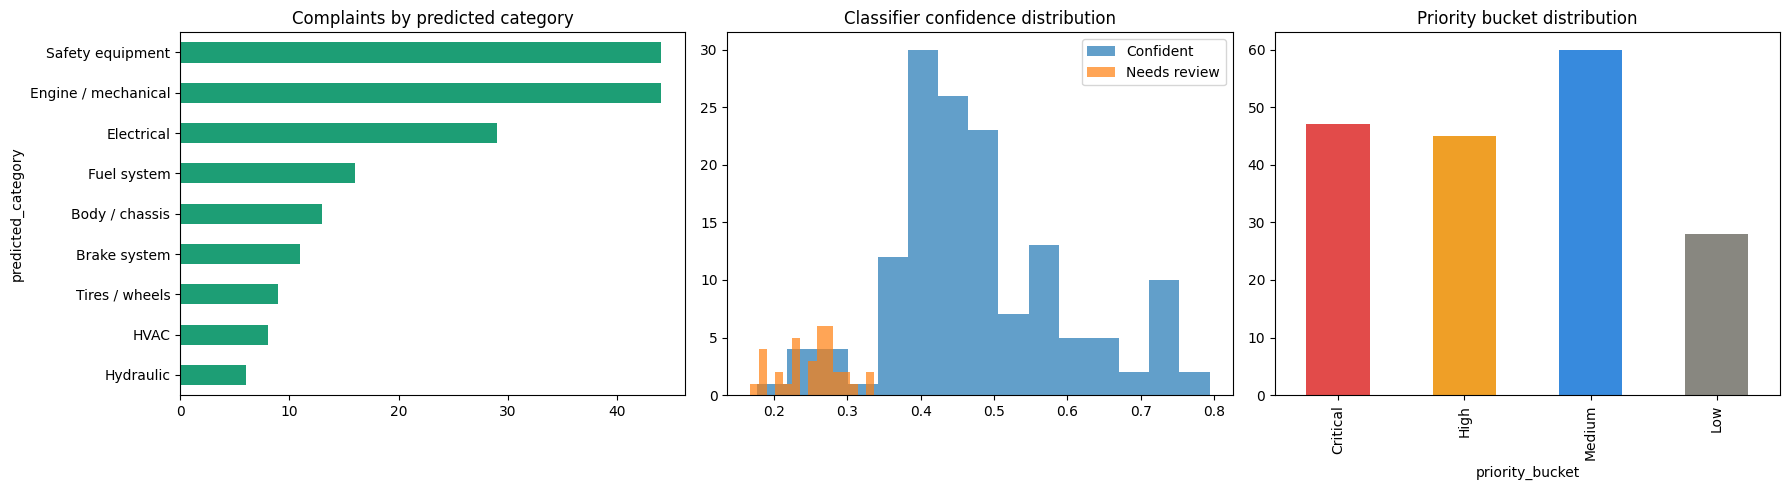

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

final_df["predicted_category"].value_counts().plot(kind="barh", ax=axes[0], color="#1D9E75")
axes[0].set_title("Complaints by predicted category")
axes[0].invert_yaxis()

axes[1].hist(final_df[~final_df["needs_human_review"]]["confidence"], bins=15, alpha=0.7, label="Confident")
axes[1].hist(final_df[final_df["needs_human_review"]]["confidence"], bins=15, alpha=0.7, label="Needs review")
axes[1].set_title("Classifier confidence distribution")
axes[1].legend()

final_df["priority_bucket"].value_counts().reindex(["Critical", "High", "Medium", "Low"]).plot(
    kind="bar", ax=axes[2], color=["#E24B4A", "#EF9F27", "#378ADD", "#888780"])
axes[2].set_title("Priority bucket distribution")

plt.tight_layout()
plt.show()